In [51]:
import requests, time, math, re, copy
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, date, timezone, timedelta
from typing import Dict, List, Optional, Tuple, Literal
from collections import defaultdict

try:
    from datetime import UTC          # Py3.11+
except ImportError:
    UTC = timezone.utc

BINANCE_BASE_URL = "https://api.binance.com"

# --- helpers / API ---
def to_symbol(coin: str, base: str) -> str | None:
    coin = coin.upper(); base = base.upper()
    if coin == base: return None
    return f"{coin}{base}"

def dt_utc_start(d: date) -> datetime:
    return datetime(d.year, d.month, d.day, tzinfo=timezone.utc)

def to_ms(dt: datetime) -> int:
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return int(dt.timestamp() * 1000)

def fetch_klines_1d(symbol: str, start_date: date, end_date: date,
                    timeout=10, retries=3, backoff=0.6) -> List[List]:
    params = {
        "symbol": symbol,
        "interval": "1d",
        "startTime": to_ms(dt_utc_start(start_date)),
        "endTime": to_ms(dt_utc_start(end_date + timedelta(days=1))) - 1,
        "limit": 1000
    }
    last_err = None
    for i in range(retries):
        try:
            r = requests.get(f"{BINANCE_BASE_URL}/api/v3/klines", params=params, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            last_err = e
            if i == retries - 1: raise
            time.sleep(backoff * (2 ** i))
    raise last_err

def daily_close_map(symbol: str, start_date: date, end_date: date, only_closed: bool = True) -> Dict[str, float]:
    """
    Map UTC date 'YYYY-MM-DD' -> close price.
    If only_closed=True, skip the last candle if it hasn't closed yet.
    """
    rows = fetch_klines_1d(symbol, start_date, end_date)
    now_ms = int(datetime.now(UTC).timestamp() * 1000)
    m: Dict[str, float] = {}
    for row in rows:
        open_ms = row[0]
        close_px = float(row[4])
        close_time_ms = row[6]
        if only_closed and close_time_ms > now_ms:
            continue
        open_dt = datetime.fromtimestamp(open_ms / 1000.0, UTC)
        day = open_dt.date().isoformat()
        m[day] = close_px
    return m


def utc_day_list(start_date: date, end_date: date) -> List[str]:
    days = []
    cur = start_date
    while cur <= end_date:
        days.append(cur.isoformat())
        cur += timedelta(days=1)
    return days

In [52]:
MD_PATH = Path("/home/miu7898/coding/markdowns/Miu/Record.md")
md_text = MD_PATH.read_text(encoding="utf-8")


def get_section_lines(md: str, title: str):
    lines = md.splitlines()
    start = -1
    for i, ln in enumerate(lines):
        if ln.strip() == f"#### {title}:":
            start = i + 1
            break
    if start == -1:
        return []
    block = []
    for j in range(start, len(lines)):
        s = lines[j]
        if s.strip().startswith("#### "):
            break
        block.append(s)
    return block

def parse_holdings_block(lines):
    holdings = {}
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#"): continue
        m = re.match(r"^([A-Za-z0-9]+)\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*$", s)
        if not m: continue
        coin, amt = m.group(1).upper(), float(m.group(2))
        holdings[coin] = amt
    return holdings

def parse_settings_block(lines):
    kv = {}
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#"): continue
        m = re.match(r"^([A-Za-z0-9_@:-]+)\s*:\s*(.+)$", s)
        if not m: continue
        k, v = m.group(1).strip(), m.group(2).strip()
        kv[k] = v
    return kv

def parse_date_flexible(s: str) -> date:
    s = s.strip()
    for fmt in ("%Y-%m-%d", "%Y/%m/%d", "%m/%d/%Y"):
        try:
            return datetime.strptime(s, fmt).date()
        except ValueError:
            pass
    raise ValueError(f"Unsupported date format: {s}")

# Read sections
holdings_lines = get_section_lines(md_text, "Initial Holdings")
settings_lines = get_section_lines(md_text, "Settings")
holdings = parse_holdings_block(holdings_lines)
settings = parse_settings_block(settings_lines)

base = settings.get("Base", "USDT").upper()

start_date = parse_date_flexible(settings.get("Start", "2025-07-04"))
today_utc = datetime.now(UTC).date()
end_date = today_utc

Action = Dict[str, object]

def parse_actions_block(lines) -> List[Action]:
    """
    Support 3 syntaxes:
      YYYY-MM-DD - Add Cost(Stock) - 1000
      YYYY-MM-DD - Out Cost(Stock) - 1000
      YYYY-MM-DD - Add Cost(Contract) - 2500
      YYYY-MM-DD - Out Cost(Contract) - 2500
      YYYY-MM-DD - Buy ADA - amount: 600, price: 0.8
      YYYY-MM-DD - Sell ADA - amount: 200, price: 0.95
    Returns a list of dicts sorted by date (string 'YYYY-MM-DD').
    Unknown/invalid lines are ignored.
    """
    out: List[Action] = []
    if not lines:
        return out

    # Regex patterns
    pat_add = re.compile(
        r"^(?P<day>\d{4}-\d{2}-\d{2})\s*-\s*Add\s+Cost\((?P<bucket>Stock|Contract)\)\s*-\s*(?P<amt>[0-9]+(?:\.[0-9]+)?)\s*$",
        re.IGNORECASE
    )
    pat_out = re.compile(
        r"^(?P<day>\d{4}-\d{2}-\d{2})\s*-\s*Out\s+Cost\((?P<bucket>Stock|Contract)\)\s*-\s*(?P<amt>[0-9]+(?:\.[0-9]+)?)\s*$",
        re.IGNORECASE
    )
    pat_trade = re.compile(
        r"^(?P<day>\d{4}-\d{2}-\d{2})\s*-\s*(?P<side>Buy|Sell)\s+(?P<coin>[A-Za-z0-9]+)\s*-\s*amount:\s*(?P<amt>[0-9]+(?:\.[0-9]+)?)\s*,\s*price:\s*(?P<px>[0-9]+(?:\.[0-9]+)?)\s*$",
        re.IGNORECASE
    )
    pat_transfer = re.compile(
        r"^(?P<day>\d{4}-\d{2}-\d{2})\s*-\s*Transfer\s+(?P<dir>StockToContract|ContractToStock)\s*-\s*(?P<amt>[0-9]+(?:\.[0-9]+)?)\s*$",
        re.IGNORECASE
    )

    for raw in lines:
        s = raw.strip()
        if not s or s.startswith("#"):
            continue

        m = pat_add.match(s)
        if m:
            day = m.group("day")
            bucket = m.group("bucket").capitalize()  # "Stock" or "Contract"
            amt = float(m.group("amt"))
            out.append({
                "date": day,
                "kind": "ADD_COST",
                "bucket": bucket,      # "Stock" | "Contract"
                "amount": amt,         # in Base currency (e.g., USDT)
            })
            continue

        m = pat_out.match(s)
        if m:
            day = m.group("day")
            bucket = m.group("bucket").capitalize()  # "Stock" or "Contract"
            amt = float(m.group("amt"))
            out.append({
                "date": day,
                "kind": "OUT_COST",
                "bucket": bucket,      # "Stock" | "Contract"
                "amount": amt,         # in Base currency (e.g., USDT)
            })
            continue
        
        m = pat_trade.match(s)
        if m:
            day = m.group("day")
            side = m.group("side").upper()          # "BUY" | "SELL"
            coin = m.group("coin").upper()
            amt  = float(m.group("amt"))
            px   = float(m.group("px"))
            out.append({
                "date": day,
                "kind": side,         # "BUY" or "SELL"
                "coin": coin,
                "amount": amt,        # coin units
                "price": px,          # in Base currency
            })
            continue

        m = pat_transfer.match(s)
        if m:
            day = m.group("day")
            direction = m.group("dir").upper()  # 'STOCKTOCONTRACT' 或 'CONTRACTTOSTOCK'
            amt = float(m.group("amt"))
            out.append({
                "date": day,
                "kind": "TRANSFER",
                "direction": direction,
                "amount": amt,
            })
            continue

    out.sort(key=lambda a: a["date"])
    return out

actions_lines = get_section_lines(md_text, "Actions")
actions = parse_actions_block(actions_lines)

if start_date > end_date:
    raise ValueError(f"Start date {start_date} is after end date {end_date}")

print("Holdings:", holdings)
print("Base:", base)
print("Date range:", start_date, "->", end_date)
print(f"[Actions] parsed {len(actions)} item(s).")
if actions:
    print(" First:", actions[0])
    print(" Last :", actions[-1])

def parse_auto_records_dates(md_text: str) -> list[date]:
    lines = get_section_lines(md_text, "Auto Records")
    out = []
    pat = re.compile(r"^(\d{4}-\d{2}-\d{2})\b")
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#"):
            continue
        m = pat.match(s)
        if m:
            out.append(datetime.strptime(m.group(1), "%Y-%m-%d").date())
    out.sort()
    return out

def parse_auto_last_date_and_state(md_text: str) -> tuple[Optional[date], Optional[str]]:
    lines = get_section_lines(md_text, "Auto Records")
    for ln in reversed(lines):
        s = ln.strip()
        if not s or s.startswith("#"):
            continue
        m = re.match(r"^(\d{4}-\d{2}-\d{2})\b.*?(STATE=([A-Z]+))?", s)
        if m:
            d = datetime.strptime(m.group(1), "%Y-%m-%d").date()
            state = m.group(3)  # 'OPEN' or None
            return d, state
    return None, None

existing_auto_dates = parse_auto_records_dates(md_text)
last_auto_date, last_date_state = parse_auto_last_date_and_state(md_text)

# Do we want intraday for "today"?
include_today_open = True  # set False if you don't want intraday updates

force_recompute_from_actions_min = True 
recompute_from = None

# Base incremental range: (last + 1) -> today(UTC)
inc_start = (last_auto_date + timedelta(days=1)) if last_auto_date else start_date
inc_end = end_date

if last_auto_date and last_date_state == "OPEN":
    inc_start = min(inc_start, last_auto_date)

force_recompute_from_actions_min = True
recompute_from: Optional[str] = None

action_dates = [datetime.strptime(a["date"], "%Y-%m-%d").date() for a in actions] if actions else []
if recompute_from:
    inc_start = min(inc_start, datetime.strptime(recompute_from, "%Y-%m-%d").date())
elif force_recompute_from_actions_min and action_dates:
    min_action_date = min(action_dates)
    if last_auto_date and min_action_date <= last_auto_date:
        inc_start = min(min_action_date, inc_start)

if include_today_open and last_auto_date == end_date:
    inc_start = min(inc_start, end_date)
    inc_end = end_date

print("Last auto date:", last_auto_date, "state:", last_date_state)
print("Incremental range:", inc_start, "->", inc_end, "(UTC)")
print("include_today_open =", include_today_open, "| last_auto_date =", last_auto_date, "| last_date_state =", last_date_state)

Holdings: {'BTC': 0.10787429, 'ETH': 6.5919396, 'ADA': 10648.8979, 'SUI': 277.952, 'USDT': 0.0}
Base: USDT
Date range: 2025-07-04 -> 2025-10-07
[Actions] parsed 14 item(s).
 First: {'date': '2025-09-01', 'kind': 'ADD_COST', 'bucket': 'Stock', 'amount': 973.381}
 Last : {'date': '2025-09-22', 'kind': 'BUY', 'coin': 'ADA', 'amount': 246.0, 'price': 0.8143}
Last auto date: 2025-10-07 state: None
Incremental range: 2025-09-01 -> 2025-10-07 (UTC)
include_today_open = True | last_auto_date = 2025-10-07 | last_date_state = None


In [53]:
def parse_costs_from_md(md_text: str):
    """
    Look for lines anywhere in the file like:
      Contract: xxx
      Stock: xxx
      Total: xxx   # ignored for initialization (we recompute)
    Returns (contract_cost_init, stock_cost_init) as floats (None -> 0.0 fallback).
    """
    contract_cost = stock_cost = None
    for ln in md_text.splitlines():
        s = ln.strip()
        m = re.match(r"^Contract\s*[:=]\s*([0-9]+(?:\.[0-9]+)?)\s*$", s, re.I)
        if m:
            contract_cost = float(m.group(1)); continue
        m = re.match(r"^Stock\s*[:=]\s*([0-9]+(?:\.[0-9]+)?)\s*$", s, re.I)
        if m:
            stock_cost = float(m.group(1)); continue
    return (contract_cost or 0.0, stock_cost or 0.0)

actions_by_day: dict[str, list[dict]] = defaultdict(list)
for a in actions:
    actions_by_day[a["date"]].append(a)

base_coin = base
contract_cost_init, stock_cost_init = parse_costs_from_md(md_text)

curr_holdings: dict[str, float] = {}
for k, v in holdings.items():
    curr_holdings[k.upper()] = float(v)
if base_coin not in curr_holdings:
    curr_holdings[base_coin] = 0.0

curr_contract_cost = float(contract_cost_init)
curr_stock_cost = float(stock_cost_init)

day_list_full = utc_day_list(start_date, end_date)
holdings_by_day: dict[str, dict[str, float]] = {}
costs_by_day: dict[str, dict[str, float]] = {}

for day in day_list_full:
    if holdings_by_day:
        curr_holdings = dict(curr_holdings)
        
    for act in actions_by_day.get(day, []):
        kind = act["kind"]
        if kind == "ADD_COST":
            bucket = act["bucket"]              # "Stock" or "Contract"
            amt = float(act["amount"])          # in base currency
            if bucket == "Stock":
                curr_stock_cost += amt
            else:
                curr_contract_cost += amt
            curr_holdings[base_coin] = curr_holdings.get(base_coin, 0.0) + amt
            
        elif kind == "OUT_COST":
            bucket = act["bucket"]              # "Stock" or "Contract"
            amt = float(act["amount"])          # in base currency
            if bucket == "Stock":
                curr_stock_cost -= amt
            else:
                curr_contract_cost -= amt
            curr_holdings[base_coin] = curr_holdings.get(base_coin, 0.0) - amt
            
        elif kind == "BUY":
            coin = act["coin"].upper()
            qty  = float(act["amount"])         # coin units
            px   = float(act["price"])          # base per coin
            # Ensure coin exists
            if coin not in curr_holdings:
                curr_holdings[coin] = 0.0
            curr_holdings[base_coin] = curr_holdings.get(base_coin, 0.0) - qty * px
            curr_holdings[coin] += qty

        elif kind == "SELL":
            coin = act["coin"].upper()
            qty  = float(act["amount"])
            px   = float(act["price"])
            if coin not in curr_holdings:
                curr_holdings[coin] = 0.0
            # Update wallet and coin position (allow negative positions if it happens)
            curr_holdings[base_coin] = curr_holdings.get(base_coin, 0.0) + qty * px
            curr_holdings[coin] -= qty

        elif kind == "TRANSFER":
            direction = act["direction"]  # 'STOCKTOCONTRACT' / 'CONTRACTTOSTOCK'
            amt = float(act["amount"])
        
            if direction == "STOCKTOCONTRACT":
                before_stock = curr_stock_cost
                curr_stock_cost = max(0.0, curr_stock_cost - amt)
                curr_contract_cost += amt
                if before_stock - amt < 0:
                    print(f"[WARN] {day} Transfer {amt} exceeds Stock cost {before_stock}; clipped Stock cost to 0.")
                curr_holdings[base_coin] = curr_holdings.get(base_coin, 0.0) - amt
        
            elif direction == "CONTRACTTOSTOCK":
                before_contract = curr_contract_cost
                curr_contract_cost = max(0.0, curr_contract_cost - amt)
                curr_stock_cost += amt
                if before_contract - amt < 0:
                    print(f"[WARN] {day} Transfer {amt} exceeds Contract cost {before_contract}; clipped Contract cost to 0.")
                curr_holdings[base_coin] = curr_holdings.get(base_coin, 0.0) + amt

        else:
            pass

    holdings_by_day[day] = dict(curr_holdings)
    total_cost_today = curr_contract_cost + curr_stock_cost
    costs_by_day[day] = {
        "Contract": curr_contract_cost,
        "Stock": curr_stock_cost,
        "Total": total_cost_today,
    }

first_day = day_list_full[0] if day_list_full else None
last_day  = day_list_full[-1] if day_list_full else None

print(f"Days: {len(day_list_full)}  from {first_day} to {last_day}")
if first_day:
    print("First day holdings:", holdings_by_day[first_day])
    print("First day costs   :", costs_by_day[first_day])
if last_day and last_day != first_day:
    print("Last day holdings :", holdings_by_day[last_day])
    print("Last day costs    :", costs_by_day[last_day])

Days: 96  from 2025-07-04 to 2025-10-07
First day holdings: {'BTC': 0.10787429, 'ETH': 6.5919396, 'ADA': 10648.8979, 'SUI': 277.952, 'USDT': 0.0}
First day costs   : {'Contract': 7500.0, 'Stock': 36479.45, 'Total': 43979.45}
Last day holdings : {'BTC': 0.07944429, 'ETH': 6.5919396, 'ADA': 13595.7979, 'SUI': 277.952, 'USDT': -19.604293199999262, 'SOL': 1.708}
Last day costs    : {'Contract': 8793.502199999999, 'Stock': 36159.328799999996, 'Total': 44952.83099999999}


In [54]:
# ===== Step C: Price × Ledger -> daily portfolio values (no file writes) =====

import math

# Sanity checks
assert 'holdings_by_day' in globals(), "Step B outputs not found: holdings_by_day"
assert 'costs_by_day' in globals(), "Step B outputs not found: costs_by_day"
assert 'inc_start' in globals() and 'inc_end' in globals(), "Incremental range not set (from Step A/Cell 1)."
assert 'include_today_open' in globals(), "Flag include_today_open not defined (from Step A/Cell 1)."

# 1) incremental day list (UTC date strings)
if inc_start > inc_end:
    day_list_inc = []
else:
    day_list_inc = utc_day_list(inc_start, inc_end)

if not day_list_inc:
    print("[INFO] Nothing to compute (incremental range is empty).")
    per_coin_values_by_day = {}
    totals_by_day = {}
    costs_total_by_day = {}
else:
    # 2) figure out which coins are present in the incremental window (exclude base since price=1)
    coins_needed = set()
    for d in day_list_inc:
        for coin, qty in holdings_by_day[d].items():
            if coin.upper() == base:
                continue
            if abs(qty) > 0:  # ignore zeros to reduce needless API
                coins_needed.add(coin.upper())

    # 3) fetch daily prices for needed coins in one go per coin
    price_map_by_coin: Dict[str, Dict[str, float]] = {}
    missing_symbols: List[str] = []

    for coin in sorted(coins_needed):
        symbol = to_symbol(coin, base)
        if symbol is None:
            # base coin never here since we excluded it above
            continue
        try:
            price_map_by_coin[coin] = daily_close_map(
                symbol,
                inc_start,
                inc_end,
                only_closed=not include_today_open  # allow open candle for "today" if desired
            )
        except Exception as e:
            print(f"[WARN] Failed to fetch {symbol}: {e}")
            price_map_by_coin[coin] = {}  # leave empty; will yield NaN
            missing_symbols.append(symbol)

    # 4) compute per-day values (holdings × price)
    per_coin_values_by_day: Dict[str, Dict[str, float]] = {}
    totals_by_day: Dict[str, float] = {}
    costs_total_by_day: Dict[str, float] = {}

    for d in day_list_inc:
        per_coin_vals: Dict[str, float] = {}
        total_val = 0.0

        # holdings for that day
        h = holdings_by_day[d]

        # base coin value (price=1.0 in base)
        base_qty = float(h.get(base, 0.0))
        if base_qty != 0.0:
            per_coin_vals[base] = base_qty * 1.0
            total_val += per_coin_vals[base]

        # other coins
        for coin, qty in h.items():
            coin = coin.upper()
            if coin == base:
                continue
            q = float(qty)
            if q == 0.0:
                continue
            px_map = price_map_by_coin.get(coin, {})
            px = px_map.get(d)
            if px is None:
                per_coin_vals[coin] = math.nan
            else:
                v = q * px
                per_coin_vals[coin] = v
                total_val += v

        per_coin_values_by_day[d] = per_coin_vals
        totals_by_day[d] = total_val

        # dynamic cost (from Step B)
        costs_total_by_day[d] = costs_by_day[d]["Total"]

    # 5) preview
    print(f"[Compute] days: {len(day_list_inc)} from {day_list_inc[0]} to {day_list_inc[-1]} (UTC)")
    # show a couple of sample lines
    for dd in (day_list_inc[:1] + day_list_inc[-1:]):
        print(f"  {dd}: TOTAL={totals_by_day[dd]:.2f} {base}, COST={costs_total_by_day[dd]:.2f}")
        # print per-coin breakdown (first 3 keys)
        keys_preview = sorted(per_coin_values_by_day[dd].keys())[:3]
        kv_preview = {k: per_coin_values_by_day[dd][k] for k in keys_preview}
        print("    breakdown preview:", {k: (round(v, 4) if isinstance(v, float) and not math.isnan(v) else v) for k, v in kv_preview.items()})

# 6) prepare Auto Records lines (incremental only; today may be STATE=OPEN)
def format_auto_record_line(day: str, base: str, total: float, per_coin: dict, *, state: Optional[str] = None) -> str:
    parts = []
    for k in sorted(per_coin.keys()):
        v = per_coin[k]
        if isinstance(v, float) and math.isnan(v):
            continue
        parts.append(f"{k}={v:.2f}")
    inside = ", ".join(parts)
    suffix = f", STATE={state}" if state else ""
    return f"{day} - TOTAL={total:.2f}, BASE={base}{suffix} [{inside}]"

auto_lines_inc: List[str] = []
if day_list_inc:
    today_str = end_date.isoformat()  # end_date should be UTC date from Cell 1
    for d in day_list_inc:
        state = "OPEN" if (include_today_open and d == today_str) else None
        auto_lines_inc.append(
            format_auto_record_line(d, base, totals_by_day[d], per_coin_values_by_day[d], state=state)
        )

# quick preview
if auto_lines_inc:
    print("[Auto preview]")
    print("\n".join(auto_lines_inc[:3]))
    if len(auto_lines_inc) > 3:
        print("...")
        print(auto_lines_inc[-3])
        print(auto_lines_inc[-2])
        print(auto_lines_inc[-1])
else:
    print("[Auto preview] No incremental lines.")


[Compute] days: 37 from 2025-09-01 to 2025-10-07 (UTC)
  2025-09-01: TOTAL=50622.85 USDT, COST=44952.83
    breakdown preview: {'ADA': 8534.0268, 'BTC': 11783.9091, 'ETH': 28440.9234}
  2025-10-07: TOTAL=54141.69 USDT, COST=44952.83
    breakdown preview: {'ADA': 11833.7825, 'BTC': 9888.2727, 'ETH': 31024.8978}
[Auto preview]
2025-09-01 - TOTAL=50622.85, BASE=USDT [ADA=8534.03, BTC=11783.91, ETH=28440.92, SUI=890.61, USDT=973.38]
2025-09-02 - TOTAL=51316.12, BASE=USDT [ADA=9170.79, BTC=11999.94, ETH=28520.03, SUI=921.91, USDT=703.45]
2025-09-03 - TOTAL=52221.10, BASE=USDT [ADA=9388.66, BTC=12050.17, ETH=29337.16, SUI=941.59, USDT=503.52]
...
2025-10-05 - TOTAL=52310.72, BASE=USDT [ADA=11381.04, BTC=9809.96, ETH=29758.12, SOL=390.38, SUI=990.82, USDT=-19.60]
2025-10-06 - TOTAL=54013.13, BASE=USDT [ADA=11848.74, BTC=9903.41, ETH=30876.71, SOL=396.85, SUI=1007.02, USDT=-19.60]
2025-10-07 - TOTAL=54141.69, BASE=USDT, STATE=OPEN [ADA=11833.78, BTC=9888.27, ETH=31024.90, SOL=400.68, SUI=1013

In [55]:
def upsert_block_by_date(md_text: str, section_title: str, new_lines: list[str]):
    """
    Generic upsert for a section "#### {section_title}:" where each line starts with 'YYYY-MM-DD - ...'.
    Merge by date; keep sorted ascending; create section if missing.
    Returns (updated_text, added_dates, updated_dates).
    """
    lines = md_text.splitlines()
    # find section
    start = None
    header = f"#### {section_title}:"
    for i, ln in enumerate(lines):
        if ln.strip() == header:
            start = i
            break

    date_re = re.compile(r'^(\d{4}-\d{2}-\d{2})\b')

    existing_map = {}
    if start is not None:
        end = len(lines)
        for j in range(start + 1, len(lines)):
            if lines[j].strip().startswith("#### "):
                end = j
                break
        for ln in lines[start + 1:end]:
            m = date_re.match(ln.strip())
            if m:
                existing_map[m.group(1)] = ln.strip()
        prefix = lines[:start]
        suffix = lines[end:]
    else:
        prefix = lines
        suffix = []

    new_map = {}
    for ln in new_lines:
        s = ln.strip()
        m = date_re.match(s)
        if m:
            new_map[m.group(1)] = s

    added_dates = sorted([d for d in new_map if d not in existing_map])
    updated_dates = sorted([d for d in new_map if d in existing_map])

    merged = dict(existing_map)
    merged.update(new_map)

    ordered_dates = sorted(merged.keys())
    block = [header] + [merged[d] for d in ordered_dates]

    if prefix and prefix[-1].strip() != "":
        prefix = prefix + [""]

    out_lines = prefix + block + suffix
    out_text = "\n".join(out_lines)
    if not out_text.endswith("\n"):
        out_text += "\n"

    return out_text, added_dates, updated_dates

# --- specific formatters ---
def format_auto_record_line(day: str, base: str, total: float, per_coin: dict, *, state: str | None = None) -> str:
    parts = []
    for k in sorted(per_coin.keys()):
        v = per_coin[k]
        if isinstance(v, float) and math.isnan(v):
            continue
        parts.append(f"{k}={v:.2f}")
    inside = ", ".join(parts)
    suffix = f", STATE={state}" if state else ""
    return f"{day} - TOTAL={total:.2f}, BASE={base}{suffix} [{inside}]"

def format_auto_holdings_line(day: str, holdings: dict, base: str, *, min_abs=1e-12) -> str:
    """
    Snapshot of end-of-day holdings after applying that day's Actions.
    Example:
      2025-08-12 - [USDT=451.26224, ADA=725.6, BTC=0.00584]
    """
    # order: base first, then alphabetical
    items = []
    for k, v in holdings.items():
        if abs(v) < min_abs:
            continue
        items.append((k.upper(), float(v)))
    items.sort(key=lambda kv: (0 if kv[0] == base else 1, kv[0]))

    def fmt(x: float) -> str:
        s = f"{x:.8f}".rstrip('0').rstrip('.')
        if s == "-0": s = "0"
        return s

    inside = ", ".join([f"{k}={fmt(v)}" for k, v in items])
    return f"{day} - [{inside}]"

if 'auto_lines_inc' not in globals():
    auto_lines_inc = []

auto_holdings_lines_inc = []
if 'day_list_inc' in globals() and day_list_inc:
    for d in day_list_inc:
        h = holdings_by_day[d]  # from Step B
        auto_holdings_lines_inc.append(
            format_auto_holdings_line(d, h, base)
        )

md_text_now = MD_PATH.read_text(encoding="utf-8")

if not auto_lines_inc:
    print("[Step D] Auto Records: no new lines.")
else:
    updated_text, added_R, updated_R = upsert_block_by_date(md_text_now, "Auto Records", auto_lines_inc)
    if updated_text != md_text_now:
        MD_PATH.write_text(updated_text, encoding="utf-8")
        md_text_now = updated_text  # keep latest buffer
        print(f"[Step D] Auto Records updated at: {MD_PATH}")
        print(f"         Added   {len(added_R)} date(s): {added_R[:5]}{' ...' if len(added_R) > 5 else ''}")
        print(f"         Updated {len(updated_R)} date(s): {updated_R[:5]}{' ...' if len(updated_R) > 5 else ''}")
    else:
        print("[Step D] Auto Records: no changes (identical).")

if not auto_holdings_lines_inc:
    print("[Step D] Auto Holdings: no new lines.")
else:
    updated_text, added_H, updated_H = upsert_block_by_date(md_text_now, "Auto Holdings", auto_holdings_lines_inc)
    if updated_text != md_text_now:
        MD_PATH.write_text(updated_text, encoding="utf-8")
        print(f"[Step D] Auto Holdings updated at: {MD_PATH}")
        print(f"         Added   {len(added_H)} date(s): {added_H[:5]}{' ...' if len(added_H) > 5 else ''}")
        print(f"         Updated {len(updated_H)} date(s): {updated_H[:5]}{' ...' if len(updated_H) > 5 else ''}")
    else:
        print("[Step D] Auto Holdings: no changes (identical).")

[Step D] Auto Records updated at: /home/miu7898/coding/markdowns/Miu/Record.md
         Added   0 date(s): []
         Updated 37 date(s): ['2025-09-01', '2025-09-02', '2025-09-03', '2025-09-04', '2025-09-05'] ...
[Step D] Auto Holdings: no changes (identical).


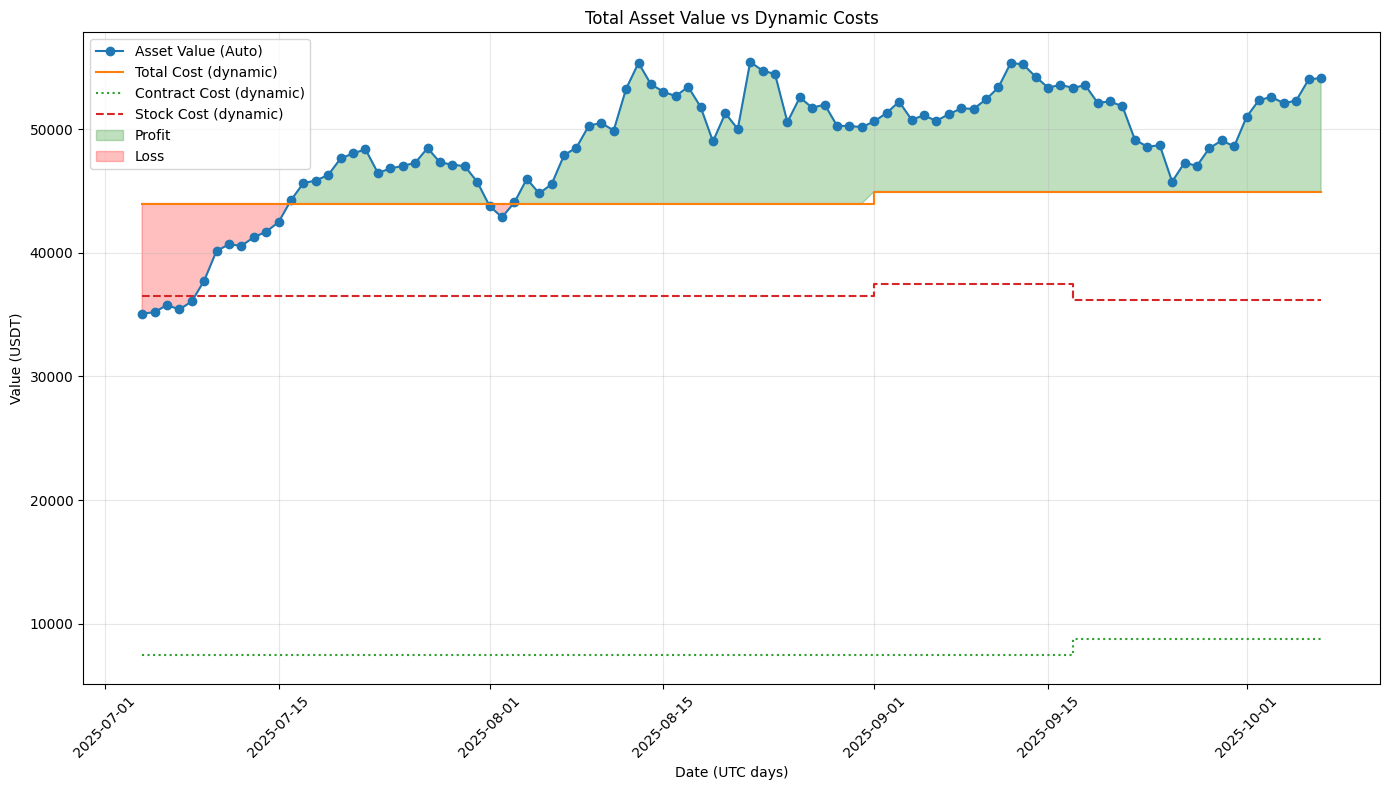

[Plot preview]
 First: 2025-07-04 Value= 35076.25 Cost= 43979.45
 Last : 2025-10-07 Value= 54141.69 Cost= 44952.83
The current profit rate : +20.44%


In [56]:
assert 'costs_by_day' in globals(), "Need 'costs_by_day' from Step B to plot dynamic costs."

md_text_plot = MD_PATH.read_text(encoding="utf-8")

def parse_auto_records(md_text: str):
    """
    Read '#### Auto Records:' lines with:
      YYYY-MM-DD - TOTAL=..., BASE=USDT[, STATE=OPEN] [USDT=..., ADA=..., ...]
    Returns a list of (datetime, total_value, date_str).
    """
    lines = get_section_lines(md_text, "Auto Records")
    rec = []
    pat = re.compile(r"^(\d{4}-\d{2}-\d{2})\s*-\s*TOTAL=([0-9]+(?:\.[0-9]+)?)\b")
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#"):
            continue
        m = pat.match(s)
        if not m:
            continue
        dt = datetime.strptime(m.group(1), "%Y-%m-%d")
        val = float(m.group(2))
        rec.append((dt, val, m.group(1)))
    rec.sort(key=lambda x: x[0])
    return rec

auto = parse_auto_records(md_text_plot)

if not auto:
    print("[Plot] No Auto Records to plot.")
else:
    plot_dates = [dt for dt, _, _ in auto]
    plot_date_strs = [ds for _, _, ds in auto]
    plot_values = [val for _, val, _ in auto]

    cost_total_series = []
    cost_contract_series = []
    cost_stock_series = []
    missing_cost_days = []

    for ds in plot_date_strs:
        c = costs_by_day.get(ds)
        if c is None:
            missing_cost_days.append(ds)
            cost_total_series.append(math.nan)
            cost_contract_series.append(math.nan)
            cost_stock_series.append(math.nan)
        else:
            cost_total_series.append(c["Total"])
            cost_contract_series.append(c["Contract"])
            cost_stock_series.append(c["Stock"])

    if missing_cost_days:
        print("[Plot] WARNING: missing costs for days:", missing_cost_days)

    plt.figure(figsize=(14, 8))
    plt.plot(plot_dates, plot_values, marker='o', label='Asset Value (Auto)')

    # Dynamic cost step lines
    plt.step(plot_dates, cost_total_series, where='post', label='Total Cost (dynamic)', linestyle='-')
    plt.step(plot_dates, cost_contract_series, where='post', label='Contract Cost (dynamic)', linestyle=':')
    plt.step(plot_dates, cost_stock_series, where='post', label='Stock Cost (dynamic)', linestyle='--')

    if all(isinstance(x, float) for x in cost_total_series):
        above = []
        for v, c in zip(plot_values, cost_total_series):
            if isinstance(c, float) and not math.isnan(c):
                above.append(v >= c)
            else:
                above.append(False)
        plt.fill_between(plot_dates, plot_values, cost_total_series, where=above,
                         interpolate=True, alpha=0.25, color='green', label='Profit')
        plt.fill_between(plot_dates, plot_values, cost_total_series, where=[not a for a in above],
                         interpolate=True, alpha=0.25, color='red', label='Loss')

    plt.xticks(rotation=45)
    plt.title("Total Asset Value vs Dynamic Costs")
    plt.xlabel("Date (UTC days)")
    plt.ylabel(f"Value ({settings.get('Base', 'USDT')})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("[Plot preview]")
    print(" First:", plot_date_strs[0], "Value=", round(plot_values[0], 2), "Cost=", round(cost_total_series[0], 2))
    print(" Last :", plot_date_strs[-1], "Value=", round(plot_values[-1], 2), "Cost=", round(cost_total_series[-1], 2))

    vals = [val for _, val, _ in auto]
    start_val, current_val = vals[0], vals[-1]

    # Change cost standard here:
    cost_to_cal = cost_total_series[-1]
    
    profit_val = (current_val/cost_to_cal - 1)
    positive = profit_val > 0
    profit_so_far = str(round(profit_val*100, 2)) + "%"
    profit_so_far = "+" + profit_so_far if positive else profit_so_far
    print(f"The current profit rate : {profit_so_far}")

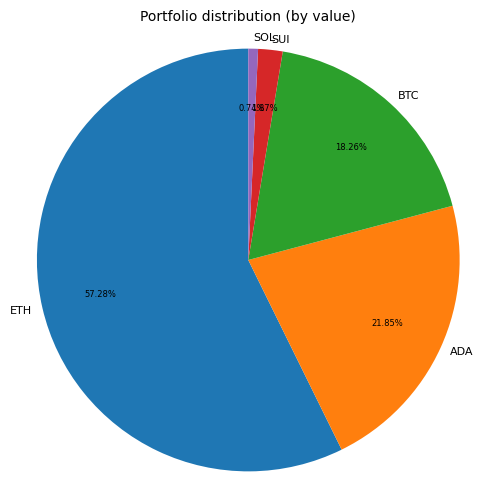

In [57]:
if not auto_lines_inc[-1]:
    print("No latest data to generate the distribution chart.")

for i, c in enumerate(auto_lines_inc[-1]):
    if c =='[':
        distribution_values = auto_lines_inc[-1][i+1:-1]

holds = distribution_values.split(", ")

def parse_holds_list(holds_list: List[str]) -> Tuple[List[str], List[float]]:
    labels, values = [], []
    
    for item in holds_list:
        if type(item) is not str or '=' not in item:
            continue
        name, val = item.split('=')
        name = name.strip().upper()
        try:
            v = float(val.strip())
        except Exception:
            continue
        if not math.isfinite(v) or v <= 0:
            continue
        labels.append(name)
        values.append(v)

    pairs = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)
    labels = [p[0] for p in pairs]
    values = [p[1] for p in pairs]
    return labels, values

def plot_holdings_distribution(holds_list, title="Portfolio distribution (by value)", label_fs=9, pct_fs=9, title_fs=11) -> None:
    labels, values = parse_holds_list(holds_list)

    if not values:
        print("No positive values to plot.")
        return
    
    plt.figure(figsize=(6,6))
    wedges, label_texts, pct_texts = plt.pie(
        values,
        labels=labels,
        autopct=lambda p: f"{p:.2f}%",
        startangle=90,
        textprops={'fontsize': label_fs},
        labeldistance=1.05,
        pctdistance=0.72
    )

    for t in pct_texts:
        t.set_fontsize(pct_fs)

    plt.title(title, fontsize=title_fs)
    plt.axis("equal")
    plt.show()

plot_holdings_distribution(holds, label_fs=8, pct_fs=6, title_fs=10)